In [35]:
# Basic packages
import numpy as np
from matplotlib import pyplot as plt
import xarray as xr
import pandas as pd
import math
from netCDF4 import Dataset

# DateTime packages
from matplotlib.dates import DateFormatter
from datetime import datetime, timedelta
import time
import matplotlib.dates as mdates

# Stats packages
import scipy
import PyCO2SYS as pyco2
import gsw
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import optuna

# Logistical packages
import requests
from importlib import reload
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import gc

# 1. Important Inputs

In [55]:
# ============================================================
# PATHS
# ============================================================

COST_DIR = Path("/Users/akbaskind/Desktop/COST_FILES")
OPT_DIR = Path("/Users/akbaskind/Desktop/Optimization")
FILE_LIST = OPT_DIR / "FileNames.xlsx"
PARAMETER_LIST = OPT_DIR / "ParameterList copy.csv"

runs = pd.read_excel(FILE_LIST)
runs = runs[["Run Name", "Cost File", "Station File"]].dropna(subset=["Run Name", "Cost File", "Station File"])

parameter_names = (
    pd.read_csv(PARAMETER_LIST)["Parameter Name"]
    .dropna()
    .astype(str)
    .str.strip()
    .tolist()
)

print(f"{len(runs)} runs")
print(f"{len(parameter_names)} parameters")

# ============================================================
# TARGET SELECTION
# ============================================================

include_benthic = True
exclude_some_benthic = True

benthic_cols = ["SOD",
                "Benthic NO3 Flux",
                "Benthic NH4 Flux",
               ]

some_benthic_cols = ["Benthic NO3 Flux",
                     "Benthic NH4 Flux",
                    ]

# ============================================================
# FILTERS AND THRESHOLDS
# ============================================================

COST_THRESHOLD = 200

# ============================================================
# METRIC DEFINITIONS FOR nRMSE
# ============================================================

metric_info = {
    "Surface Temperature": ("temp_mod", "temp_obs"),
    "Bottom Temperature":  ("temp_mod", "temp_obs"),
    # "Total Temperature":   ("temp_mod", "temp_obs"),

    "Surface Salinity": ("salt_mod", "salt_obs"),
    "Bottom Salinity":  ("salt_mod", "salt_obs"),
    # "Total Salinity":   ("salt_mod", "salt_obs"),

    "Surface pH": ("pH_mod", "pH_obs"),
    "Bottom pH":  ("pH_mod", "pH_obs"),
    # "Total pH":   ("pH_mod", "pH_obs"),

    "Surface Oxygen": ("oxygen_mod", "oxygen_obs"),
    "Bottom Oxygen":  ("oxygen_mod", "oxygen_obs"),
    # "Total Oxygen":   ("oxygen_mod", "oxygen_obs"),

    "Surface NO3": ("NO3_mod", "NO3_obs"),
    "Bottom NO3":  ("NO3_mod", "NO3_obs"),
    # "Total NO3":   ("NO3_mod", "NO3_obs"),

    "Surface NH4": ("NH4_mod", "NH4_obs"),
    "Bottom NH4":  ("NH4_mod", "NH4_obs"),
    # "Total NH4":   ("NH4_mod", "NH4_obs"),

    "Surface Si": ("Si_mod", "Si_obs"),
    "Bottom Si":  ("Si_mod", "Si_obs"),
    # "Total Si":   ("Si_mod", "Si_obs"),

    "Secchi Depth": ("SD_mod", "SD_obs"),

    "SOD": ("sed_o2_mod", "sed_o2_obs"),
    "Benthic NO3 Flux": ("sed_no3_mod", "sed_no3_obs"),
    "Benthic NH4 Flux": ("sed_nh4_mod", "sed_nh4_obs"),
}

if not include_benthic:
    metric_info = dict([i for i in metric_info.items() if i[0] not in benthic_cols])
elif exclude_some_benthic:
    metric_info = dict([i for i in metric_info.items() if i[0] not in some_benthic_cols])
    

print(f"\nNumber of nRMSE metrics = {len(metric_info)}")
print(f"nRMSE metrics: {list(metric_info.keys())}")

# ============================================================
# METRIC DEFINITIONS FOR COST
# ============================================================

cost_components = {"Surface Temperature": "temperature_cost",
                   "Bottom Temperature": "temperature_cost",
                   "Surface Salinity": "salt_cost",
                   "Bottom Salinity": "salt_cost",
                   "Surface pH": "pH_cost",
                   "Bottom pH": "pH_cost", 
                   "Surface Oxygen": "oxygen_cost",
                   "Bottom Oxygen": "oxygen_cost",
                   "Surface NO3": "NO3_cost",
                   "Bottom NO3": "NO3_cost",
                   "Surface NH4": "NH4_cost",
                   "Bottom NH4": "NH4_cost",
                   "Surface Si": "Si_cost",
                   "Bottom Si": "Si_cost",
                   "Secchi Depth": "SD_cost",
                   "SOD": "sed_o2_cost",
                   "Benthic NO3 Flux": "sed_no3_cost",
                   "Benthic NH4 Flux": "sed_nh4_cost"
                  }

cost_weights    = {"Surface Temperature": 1,
                   "Bottom Temperature": 1,
                   "Surface Salinity": 1,
                   "Bottom Salinity": 1,
                   "Surface pH": 1,
                   "Bottom pH": 1, 
                   "Surface Oxygen": 1,
                   "Bottom Oxygen": 1,
                   "Surface NO3": 1,
                   "Bottom NO3": 1,
                   "Surface NH4": 1,
                   "Bottom NH4": 1,
                   "Surface Si": 1,
                   "Bottom Si": 1,
                   "Secchi Depth": 1,
                   "SOD": 1,
                   "Benthic NO3 Flux": 1,
                   "Benthic NH4 Flux": 1
                  }

if not include_benthic:
    cost_components = dict([i for i in cost_components.items() if i[0] not in benthic_cols])
    cost_weights = dict([i for i in cost_weights.items() if i[0] not in benthic_cols])
elif exclude_some_benthic:
    cost_components = dict([i for i in cost_components.items() if i[0] not in some_benthic_cols])
    cost_weights = dict([i for i in cost_weights.items() if i[0] not in some_benthic_cols])

print(f"\nNumber of cost targets = {len(cost_components)}")
print(f"Cost metrics: {list(cost_components.keys())}")

# ============================================================
# OPTUNA STUDY SETTINGS
# ============================================================

STUDY_NAME = "model_calibration"

STORAGE_FILE = OPT_DIR / "model_calibration.db"

STORAGE = f"sqlite:///{STORAGE_FILE}"

print(f"\nStudy name: {STUDY_NAME}")
print(f"Storage:    {STORAGE_FILE}")

GENERATE_NEW_CANDIDATES = True

N_CANDIDATES = 4

100 runs
74 parameters

Number of nRMSE metrics = 16
nRMSE metrics: ['Surface Temperature', 'Bottom Temperature', 'Surface Salinity', 'Bottom Salinity', 'Surface pH', 'Bottom pH', 'Surface Oxygen', 'Bottom Oxygen', 'Surface NO3', 'Bottom NO3', 'Surface NH4', 'Bottom NH4', 'Surface Si', 'Bottom Si', 'Secchi Depth', 'SOD']

Number of cost targets = 16
Cost metrics: ['Surface Temperature', 'Bottom Temperature', 'Surface Salinity', 'Bottom Salinity', 'Surface pH', 'Bottom pH', 'Surface Oxygen', 'Bottom Oxygen', 'Surface NO3', 'Bottom NO3', 'Surface NH4', 'Bottom NH4', 'Surface Si', 'Bottom Si', 'Secchi Depth', 'SOD']

Study name: model_calibration
Storage:    /Users/akbaskind/Desktop/Optimization/model_calibration.db


# 2. Functions

## 2.1. nRMSE functions

In [37]:
# ============================================================
# OBSERVATIONAL ERROR
# ============================================================

def get_stderr(var_obs, obs_mean):

    if var_obs.startswith("sed"):
        return obs_mean

    elif var_obs.startswith("pH"):
        return 0.1

    elif var_obs.startswith("temp"):
        return 0.01

    elif var_obs.startswith("salt"):
        return 0.005 * obs_mean

    elif var_obs.startswith("oxy"):
        return 3.125

    elif var_obs.startswith("N"):
        return 0.1

    elif var_obs.startswith("Si"):
        return 0.1

    elif var_obs.startswith("SD"):
        return 0.2

    else:
        return 0


# ============================================================
# CALCULATE ONE RMSE*
# ============================================================

def calculate_rmse_star(ds, metric_name, var_mod, var_obs):
    
    if var_mod not in ds.variables or var_obs not in ds.variables:
        return np.nan

    # --------------------------------
    # Select depth
    # --------------------------------

    if metric_name.startswith("Surface"):

        mod = ds[var_mod].isel(Depth=0).values.ravel()
        obs = ds[var_obs].isel(Depth=0).values.ravel()

    elif metric_name.startswith("Bottom"):

        mod = ds[var_mod].isel(Depth=1).values.ravel()
        obs = ds[var_obs].isel(Depth=1).values.ravel()

    else:

        mod = ds[var_mod].values.ravel()
        obs = ds[var_obs].values.ravel()


    # --------------------------------
    # Means / standard deviations
    # --------------------------------

    mod_mean = np.nanmean(mod)
    obs_mean = np.nanmean(obs)

    std_mod = np.nanstd(mod)
    std_obs = np.nanstd(obs)


    # --------------------------------
    # Add observational uncertainty
    # --------------------------------

    stderr = get_stderr(var_obs, obs_mean)

    std_obs = np.sqrt(
        std_obs**2 +
        stderr**2
    )


    # --------------------------------
    # Correlation
    # --------------------------------

    covariance = (
        (mod - mod_mean) *
        (obs - obs_mean)
    )

    valid = ~np.isnan(covariance)

    N = valid.sum()

    if N == 0:
        return np.nan

    R = (
        covariance[valid].sum() /
        (std_mod * std_obs)
    )

    R = R / N


    # --------------------------------
    # Normalized standard deviation
    # --------------------------------

    std_norm = std_mod / std_obs


    # --------------------------------
    # Sign
    # --------------------------------

    sign = np.sign(std_mod - std_obs)


    # --------------------------------
    # RMSD*'
    # --------------------------------

    inside = (
        1 +
        std_norm**2 -
        2 * std_norm * R
    )

    # Protect against tiny numerical negatives
    if inside < 0:
        inside = abs(inside)

    rmsd_star = np.sqrt(inside) * sign

    return rmsd_star

## 2.2. Cost functions

In [38]:
def calculate_cost(ds, active_rmse_cols, cost_components, cost_weights):
    
    total_cost = 0
    
    for cost, key in cost_components.items():
        if cost in active_rmse_cols:
            
            if cost.startswith("Surface"):
                weight = cost_weights[cost]
                cost_comp = float(ds[key][0]) * weight*weight
            elif cost.startswith("Bottom"):
                weight = cost_weights[cost]
                cost_comp = float(ds[key][0]) * weight*weight
            else:
                weight = cost_weights[cost]
                cost_comp = float(ds[key]) * weight*weight
                
            total_cost = total_cost + cost_comp
    return total_cost

## 2.3. Parameter extraction functions

In [39]:
def get_parameter_values(ds, parameter_name):

    # Parameter doesn't exist in this file
    # Don't create a new scalar-named column
    if parameter_name not in ds.variables:
        return {}

    var = ds.variables[parameter_name]

    try:

        # --------------------------------
        # Scalar parameter
        # --------------------------------
        if var.ndim == 0:

            value = var[...]

            if np.ma.is_masked(value):
                value = np.nan

            return {
                parameter_name: np.asarray(value).item()
            }

        # --------------------------------
        # Parameter with dimensions
        # --------------------------------
        values = np.asarray(var[:]).squeeze()

        # Squeezes down to a scalar
        if values.ndim == 0:

            return {
                parameter_name: values.item()
            }

        # --------------------------------
        # One-dimensional parameter
        # --------------------------------
        if values.ndim == 1:

            dim_name = var.dimensions[0]

            return {
                f"{parameter_name}_{dim_name}{i}": value
                for i, value in enumerate(values)
            }

        # --------------------------------
        # Anything else
        # --------------------------------
        values = values.ravel()

        return {
            f"{parameter_name}_{i}": value
            for i, value in enumerate(values)
        }

    except Exception as e:

        print(
            f"    Could not read {parameter_name}: {e}"
        )

        return {}

# 3. Get nRMSE, cost, and parameter values

In [40]:
# ============================================================
# PROCESS EACH MODEL RUN ONCE
#   - RMSE metrics
#   - Cost
#   - Parameters
# ============================================================

all_results = []

missing_cost_files = []
missing_station_files = []

for n, (_, row) in enumerate(runs.iterrows(), start=1):

    run_name = row["Run Name"]
    cost_file = row["Cost File"]
    station_file = row["Station File"]

    cost_path = COST_DIR / cost_file
    station_path = COST_DIR / station_file

    print(f"\n[{n}/{len(runs)}] Processing {run_name}")
    print(f"  Cost file:    {cost_path.name}")
    print(f"  Station file: {station_path.name}")

    # Everything for this run goes into ONE dictionary
    run_results = {
        "Run Name": run_name,
        "Cost File": cost_file,
        "Station File": station_file
    }

    # ========================================================
    # COST FILE
    #   1. Calculate RMSE metrics
    #   2. Calculate total cost
    # ========================================================

    try:

        with xr.open_dataset(cost_path) as ds:

            # --------------------------
            # RMSE metrics
            # --------------------------
            for metric_name, (var_mod, var_obs) in metric_info.items():

                rmse = calculate_rmse_star(
                    ds,
                    metric_name,
                    var_mod,
                    var_obs
                )

                run_results[metric_name] = rmse

            # --------------------------
            # Combined cost
            # --------------------------
            cost = calculate_cost(
                ds,
                cost_components.keys(),
                cost_components,
                cost_weights
            )

            run_results["Cost"] = cost

        run_results["Cost Status"] = "Success"

    except Exception as e:

        print(f"  COST FILE ERROR: {e}")

        run_results["Cost Status"] = f"ERROR: {e}"

        # Make sure expected outputs exist
        for metric_name in metric_info:
            run_results.setdefault(metric_name, np.nan)

        run_results.setdefault("Cost", np.nan)

        missing_cost_files.append(cost_path.name)

    # ========================================================
    # STATION FILE
    #   Extract model parameters
    # ========================================================

    try:

        with Dataset(station_path, mode="r") as ds:

            for parameter in parameter_names:

                parameter_values = get_parameter_values(
                    ds,
                    parameter
                )

                run_results.update(parameter_values)

        run_results["Parameter Status"] = "Success"

    except Exception as e:

        print(f"  STATION FILE ERROR: {e}")

        run_results["Parameter Status"] = f"ERROR: {e}"

        # Fill parameters with NaN if station file cannot be read
        for parameter in parameter_names:
            run_results.setdefault(parameter, np.nan)

        missing_station_files.append(station_path.name)

    # ========================================================
    # SAVE THIS RUN
    # ========================================================

    all_results.append(run_results)

    gc.collect()


# ============================================================
# CREATE FINAL DATAFRAME
# ============================================================

DF_opt = pd.DataFrame(all_results)

# Safety cleanup
DF_opt = DF_opt.dropna(
    axis=1,
    how="all"
)


[1/100] Processing A13
  Cost file:    A13.nc
  Station file: ocean_sta_A13.nc

[2/100] Processing DU_Mar16
  Cost file:    DU_Mar16.nc
  Station file: ocean_sta_DU_Mar16.nc

[3/100] Processing DU
  Cost file:    DU.nc
  Station file: ocean_sta_DU.nc

[4/100] Processing A17
  Cost file:    A17.nc
  Station file: ocean_sta_A17.nc

[5/100] Processing C11
  Cost file:    C11.nc
  Station file: ocean_sta_C11.nc

[6/100] Processing A16
  Cost file:    A16.nc
  Station file: ocean_sta_A16.nc

[7/100] Processing C10
  Cost file:    C10.nc
  Station file: ocean_sta_C10.nc

[8/100] Processing A12
  Cost file:    A12.nc
  Station file: ocean_sta_A12.nc

[9/100] Processing 2005_CTRL
  Cost file:    2005_CTRL.nc
  Station file: ocean_sta_2005_CTRL.nc
  COST FILE ERROR: [Errno 2] No such file or directory: '/Users/akbaskind/Desktop/COST_FILES/2005_CTRL.nc'

[10/100] Processing D10
  Cost file:    D10.nc
  Station file: ocean_sta_D10.nc

[11/100] Processing C5
  Cost file:    C5.nc
  Station file: 

## 3.1. Missing files

In [41]:
# missing cost files
missing_cost_files = DF_opt["Run Name"][(DF_opt["Cost Status"] != "Success") &
                                        (DF_opt["Parameter Status"] == "Success")]
print(f"Missing cost files with station files: {list(missing_cost_files)}\n")

# missing SOD but existing cost file
missing_SOD = DF_opt["Run Name"][(DF_opt["Cost Status"] == "Success") &
                                 (DF_opt["Parameter Status"] != "Success") & 
                                 (DF_opt["SOD"].isna())]
print(f"Missing SOD with cost file: {list(missing_SOD)}\n")

# Really high cost
high_cost = DF_opt["Run Name"][DF_opt["Cost"] > COST_THRESHOLD]
print(f"Really high cost: {list(high_cost)}\n")

Missing cost files with station files: ['2005_CTRL', 'C4', 'D16', 'A3', 'A2', 'D17', 'A9', 'A14']

Missing SOD with cost file: []

Really high cost: ['A13', 'DU_Mar16', 'A12', 'D10', 'A1', 'D14', 'D4', 'A5', 'D5', 'A4', 'D11', 'A7', 'D6', 'D12', 'D13', 'D10-2', 'A6', 'D7', 'A11', 'D18', 'D8', 'A10', 'D19', 'D9', 'A8']



In [42]:
print("Missing values per RMSE column:")
print(DF_opt[metric_info.keys()].isna().sum())

print("\nAll values finite:")
print(np.isfinite(DF_opt[metric_info.keys()]).all())

Missing values per RMSE column:
Surface Temperature    4
Bottom Temperature     4
Surface Salinity       4
Bottom Salinity        4
Surface pH             4
Bottom pH              4
Surface Oxygen         4
Bottom Oxygen          4
Surface NO3            4
Bottom NO3             4
Surface NH4            4
Bottom NH4             4
Surface Si             5
Bottom Si              5
Secchi Depth           4
SOD                    9
dtype: int64

All values finite:
Surface Temperature    False
Bottom Temperature     False
Surface Salinity       False
Bottom Salinity        False
Surface pH             False
Bottom pH              False
Surface Oxygen         False
Bottom Oxygen          False
Surface NO3            False
Bottom NO3             False
Surface NH4            False
Bottom NH4             False
Surface Si             False
Bottom Si              False
Secchi Depth           False
SOD                    False
dtype: bool


# 4. Clean dataframe for objective nRMSEs and varied parameters

## 4.1. Objective nRMSE 
Absolute value of signed nRMSE

In [43]:
active_rmse_cols = metric_info.keys()

active_objective_cols = []

for col in active_rmse_cols:
    new_col = f"{col} Objective"
    DF_opt[new_col] = DF_opt[col].abs()
    active_objective_cols.append(new_col)
    
DF_opt[active_objective_cols].describe().T[["min",
                                            "25%",
                                            "50%",
                                            "75%",
                                            "max"]]

,min,25%,50%,75%,max
Surface Temperature Objective,0.263057,0.268273,0.271299,0.320214,0.361455
Bottom Temperature Objective,0.250133,0.259403,0.273896,0.439991,0.648028
Surface Salinity Objective,0.837249,0.916436,0.943041,1.084649,4.238856
Bottom Salinity Objective,0.186457,0.230392,0.315107,1.070108,2.694552
Surface pH Objective,0.897703,0.950298,1.034328,1.220436,6.124632
Bottom pH Objective,0.719044,0.882822,1.029704,1.167655,7.285670
Surface Oxygen Objective,0.553251,0.597000,0.684842,0.764283,0.863538
Bottom Oxygen Objective,0.508974,0.637609,0.680442,0.758351,1.159501
Surface NO3 Objective,0.597800,0.782121,0.948167,1.512690,4.132480
Bottom NO3 Objective,0.629221,0.839368,1.087244,1.552397,3.022346


## 4.2. Remove unreasonably large costs

In [44]:
print(f"Dropping any run with a cost over {COST_THRESHOLD}, as that suggests something went wrong.\n")

old_len = len(DF_opt)

DF_opt = DF_opt[DF_opt["Cost"] < COST_THRESHOLD].reset_index(drop = True)

new_len = len(DF_opt)

print("Number of runs:", len(DF_opt))
print("Number of runs dropped:", old_len - new_len)

del old_len, new_len

Dropping any run with a cost over 200, as that suggests something went wrong.

Number of runs: 65
Number of runs dropped: 35


## 4.2. Varied parameters

In [45]:
parameter_cols = [
    col for col in DF_opt.columns
    if (
        col not in ["Run Name", "Station File", "Parameter Status", "Cost File", "Cost", "Cost Status"]
        and col not in active_rmse_cols
        and col not in active_objective_cols
    )
]

In [46]:
parameter_variation = DF_opt[parameter_cols].nunique().sort_values()

varied_parameter_cols = parameter_variation[
    parameter_variation > 1
].index.tolist()

print("Parameters that varied:", len(varied_parameter_cols))
print(varied_parameter_cols)
print("\nParameters that never varied:",
      (parameter_variation == 1).sum())


Parameters that varied: 38
['rrg1', 'rrg2', 'rrb1', 'wsp', 'pis2', 'aksio4s2', 'bgamma0', 'rrb2', 'bfs_nspc1', 'bao2', 'bfs_nspc0', 'amaxs1', 'Chl2cs1_m', 'aknh4s1', 'akno3s1', 'Chl2cs2_m', 'bgamma3', 'bgamma5s', 'wsdsi', 'gmaxs2', 'bgamma4', 'amaxs2', 'gmaxs1', 'akno3s2', 'akz2', 'reg2', 'reg1', 'akz1', 'bgamma6', 'beta2', 'beta1', 'bUmax_nspc0', 'bnit', 'wsd', 'bUmax_nspc1', 'bgamma7', 'bdenit', 'bgamma5']

Parameters that never varied: 48


## 4.3. Clean the dataframe

In [47]:
DF_optuna = DF_opt[["Run Name"] + ["Cost"] +
                    varied_parameter_cols +
                    active_objective_cols].copy()

print(DF_optuna.shape)
display(DF_optuna.head())

(65, 56)


,Run Name,Cost,rrg1,rrg2,rrb1,wsp,pis2,aksio4s2,bgamma0,rrb2,...,Surface Oxygen Objective,Bottom Oxygen Objective,Surface NO3 Objective,Bottom NO3 Objective,Surface NH4 Objective,Bottom NH4 Objective,Surface Si Objective,Bottom Si Objective,Secchi Depth Objective,SOD Objective
0,DU,34.504838,0.1,0.1,0.2,0.4,1.59,2.0,0.025,0.2,...,0.789026,0.826694,1.135046,1.065471,0.800463,1.186002,0.991277,0.968272,1.058675,1.054923
1,A17,46.651095,0.2,0.2,0.3,0.3,1.59,1.0,0.050,0.3,...,0.589592,0.628134,0.924558,1.090406,0.824347,0.957371,0.747530,0.846631,1.240319,1.053763
2,C11,28.036106,0.1,0.1,0.2,0.4,1.59,2.0,0.025,0.2,...,0.734506,0.754195,0.807021,0.886873,0.899166,1.040742,0.983584,1.235111,1.129166,0.950250
3,A16,45.621414,0.2,0.2,0.3,0.3,1.59,1.0,0.050,0.3,...,0.592115,0.642817,0.904776,1.067467,0.810154,0.947802,0.755649,0.860747,1.240828,1.057055
4,C10,29.516924,0.1,0.1,0.2,0.4,1.59,2.0,0.025,0.2,...,0.693142,0.737725,0.813169,0.856909,0.934474,1.083954,1.030878,1.265556,0.982595,0.950236


# 5. Load optuna study

## 5.1. Load the study

In [48]:
# ============================================================
# CREATE OR LOAD STUDY
# ============================================================

sampler = optuna.samplers.TPESampler(
    n_startup_trials=10,
    multivariate=True,
    seed=42
)

study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE,
    direction="minimize",
    sampler=sampler,
    load_if_exists=True
)

print(f"\nLoaded study: {study.study_name}")
print(f"Number of trials currently stored: {len(study.trials)}")

[I 2026-09-10 07:44:01,979] Using an existing study with name 'model_calibration' instead of creating a new one.



Loaded study: model_calibration
Number of trials currently stored: 64


## 5.2. Parameter distributions

In [49]:
# ============================================================
# PARAMETER LOOKUP TABLE
# ============================================================
parameter_summary = pd.DataFrame({
    "Parameter": varied_parameter_cols,
    "Low": [DF_optuna[p].min() for p in varied_parameter_cols],
    "High": [DF_optuna[p].max() for p in varied_parameter_cols],
    "Unique Values": [
        DF_optuna[p].nunique(dropna=True)
        for p in varied_parameter_cols
    ]
})

parameter_summary = parameter_summary[
    parameter_summary["Unique Values"] > 1
].reset_index(drop=True)


# Convert to Optuna bounds dictionary
all_parameter_bounds = {
    row["Parameter"]: (row["Low"], row["High"])
    for _, row in parameter_summary.iterrows()
}

display(parameter_summary)

# ============================================================
# MANUAL BOUND OVERRIDES
# ============================================================

all_parameter_bounds["bdenit"] = (1.0, DF_optuna["bdenit"].max())


# ============================================================
# PARAMETERS TO OPTIMIZE
# ============================================================

active_parameters = [
    "bgamma7",
    "bgamma5",
    "bUmax_nspc1",
    "wsd",
    "bnit",
    "bdenit",
    "beta1",
    "beta2",
    "bgamma6",
    "akz1",
    "akz2",
    "reg1",
    "reg2"
]

parameter_bounds = {
    p: all_parameter_bounds[p]
    for p in active_parameters
}

print("Parameters being optimized:")

for parameter in active_parameters:
    low, high = all_parameter_bounds[parameter]
    print(f"  {parameter}: {low} - {high}")

,Parameter,Low,High,Unique Values
0,rrg1,0.10000,0.200000,2
1,rrg2,0.10000,0.200000,2
2,rrb1,0.20000,0.300000,2
3,wsp,0.30000,0.400000,2
4,pis2,1.59000,5.590000,2
5,aksio4s2,1.00000,2.000000,2
6,bgamma0,0.02500,0.050000,2
7,rrb2,0.20000,0.300000,2
8,bfs_nspc1,0.35000,0.650000,2
9,bao2,1.89400,2.000000,2


Parameters being optimized:
  bgamma7: 0.25 - 0.4961446158917879
  bgamma5: 0.15 - 0.3997598854239505
  bUmax_nspc1: 0.00274 - 0.02
  wsd: 2.0 - 5.0
  bnit: 0.15 - 0.2987851871698918
  bdenit: 1.0 - 28.979636342517402
  beta1: 0.5 - 2.25
  beta2: 0.3 - 1.75
  bgamma6: 0.005 - 0.1
  akz1: 0.5 - 1.0
  akz2: 0.5 - 2.0
  reg1: 0.1 - 0.2
  reg2: 0.05 - 0.1


## 5.3. Add historical runs

In [50]:
# ============================================================
# ADD HISTORICAL COMPLETED RUNS TO OPTUNA
# ============================================================

existing_run_names = {
    trial.user_attrs.get("Run Name")
    for trial in study.trials
    if trial.user_attrs.get("Run Name") is not None
}

n_added = 0
n_already_present = 0
n_missing_parameters = 0
n_missing_cost = 0
n_outside_bounds = 0

for _, row in DF_optuna.iterrows():

    run_name = row["Run Name"]

    # --------------------------------------------------------
    # Skip runs already stored in Optuna
    # --------------------------------------------------------

    if run_name in existing_run_names:
        n_already_present += 1
        continue

    # --------------------------------------------------------
    # Require values for all active parameters
    # --------------------------------------------------------

    if row[active_parameters].isna().any():
        n_missing_parameters += 1
        continue

    # --------------------------------------------------------
    # Require Cost
    # --------------------------------------------------------

    if pd.isna(row["Cost"]) or not np.isfinite(row["Cost"]):
        n_missing_cost += 1
        continue

    # --------------------------------------------------------
    # Require parameter values to fall within Optuna bounds
    # --------------------------------------------------------

    outside_bounds = False

    for p in active_parameters:
        value = float(row[p])
        low, high = parameter_bounds[p]

        if value < low or value > high:
            outside_bounds = True
            break

    if outside_bounds:
        n_outside_bounds += 1
        continue

    # --------------------------------------------------------
    # Parameter values
    # --------------------------------------------------------

    params = {
        p: float(row[p])
        for p in active_parameters
    }

    distributions = {
        p: optuna.distributions.FloatDistribution(
            low=parameter_bounds[p][0],
            high=parameter_bounds[p][1]
        )
        for p in active_parameters
    }

    # --------------------------------------------------------
    # Store individual objectives as trial metadata
    # --------------------------------------------------------

    objective_values = {}

    for objective in active_objective_cols:

        value = row[objective]

        if pd.notna(value) and np.isfinite(value):
            objective_values[objective] = float(value)
        else:
            objective_values[objective] = None

    # --------------------------------------------------------
    # Create completed trial
    # --------------------------------------------------------

    completed_trial = optuna.trial.create_trial(
        params=params,
        distributions=distributions,
        value=float(row["Cost"]),
        state=optuna.trial.TrialState.COMPLETE,
        user_attrs={
            "Run Name": run_name,
            "Source": "Historical",
            "Objectives": objective_values
        }
    )

    study.add_trial(completed_trial)

    existing_run_names.add(run_name)

    n_added += 1


print("\nHistorical trial import:")
print(f"  Added:               {n_added}")
print(f"  Already present:     {n_already_present}")
print(f"  Missing parameters:  {n_missing_parameters}")
print(f"  Missing Cost:        {n_missing_cost}")
print(f"  Outside bounds:      {n_outside_bounds}")

print(f"\nTotal Optuna trials: {len(study.trials)}")


Historical trial import:
  Added:               0
  Already present:     65
  Missing parameters:  0
  Missing Cost:        0
  Outside bounds:      0

Total Optuna trials: 64


# 6. Candidates

## 6.1. Check current study status

In [56]:
# ============================================================
# CHECK CURRENT STUDY STATUS
# ============================================================

print(f"Study: {study.study_name}")
print(f"Total trials: {len(study.trials)}")

for state in optuna.trial.TrialState:
    n = sum(trial.state == state for trial in study.trials)
    
    if n > 0:
        print(f"  {state.name}: {n}")

Study: model_calibration
Total trials: 64
  COMPLETE: 64


In [57]:
# ============================================================
# LOAD CURRENT RUNNING CANDIDATES
# ============================================================

running_trials = [
    trial
    for trial in study.trials
    if trial.state == optuna.trial.TrialState.RUNNING
]

print(f"Running trials: {len(running_trials)}")
candidate_results = []

for trial in running_trials:
    
    print(
        f"  Trial {trial.number}: "
        f"{trial.user_attrs.get('Run Name', 'No Run Name')}"
    )

    candidate_results.append({
        "Run Name": trial.user_attrs.get("Run Name"),
        "Trial Number": trial.number,
        **trial.params
    })

DF_candidates = pd.DataFrame(candidate_results)

display(DF_candidates)

Running trials: 0


""


## 6.2. Generate candidate parameter sets

In [58]:
# ============================================================
# GENERATE NEW OPTUNA CANDIDATES
# ============================================================

# ------------------------------------------------------------
# Check for existing running trials
# ------------------------------------------------------------

running_trials = [
    trial
    for trial in study.trials
    if trial.state == optuna.trial.TrialState.RUNNING
]


# ------------------------------------------------------------
# Generate candidates only when explicitly requested
# ------------------------------------------------------------

if GENERATE_NEW_CANDIDATES:

    if len(running_trials) > 0:

        print(
            f"NOT generating new candidates because "
            f"{len(running_trials)} trials are already RUNNING."
        )

        for trial in running_trials:
            print(
                f"  Trial {trial.number}: "
                f"{trial.user_attrs.get('Run Name', 'No Run Name')}"
            )

    else:

        candidate_results = []

        for i in range(N_CANDIDATES):

            trial = study.ask()

            run_name = f"OPTUNA_{trial.number}"

            trial.set_user_attr(
                "Run Name",
                run_name
            )

            trial.set_user_attr(
                "Source",
                "Optuna suggestion"
            )

            params = {}

            for parameter, (low, high) in parameter_bounds.items():

                params[parameter] = trial.suggest_float(
                    parameter,
                    low,
                    high
                )

            candidate_results.append({
                "Run Name": run_name,
                "Trial Number": trial.number,
                **params
            })

        DF_candidates = pd.DataFrame(candidate_results)

        display(DF_candidates)


else:

    print("Candidate generation is OFF.")
    print(
        "Set GENERATE_NEW_CANDIDATES = True "
        "when you are ready for another batch."
    )
    
    print(
            f"NOT generating new candidates because "
            f"{len(running_trials)} trials are already RUNNING."
        )

    for trial in running_trials:
        print(
            f"  Trial {trial.number}: "
            f"{trial.user_attrs.get('Run Name', 'No Run Name')}"
        )

,Run Name,Trial Number,bgamma7,bgamma5,bUmax_nspc1,wsd,bnit,bdenit,beta1,beta2,bgamma6,akz1,akz2,reg1,reg2
0,OPTUNA_64,64,0.279993,0.150611,0.006389,2.246103,0.178588,6.847478,0.512112,0.373785,0.006077,0.572739,0.994623,0.116679,0.078731
1,OPTUNA_65,65,0.272892,0.152200,0.003193,2.386866,0.158613,6.215863,0.774188,0.643514,0.065595,0.672197,0.773649,0.101957,0.097172
2,OPTUNA_66,66,0.282966,0.152456,0.004394,2.575005,0.162066,7.161466,1.092628,0.432543,0.037491,0.568588,0.501530,0.123504,0.081909
3,OPTUNA_67,67,0.279042,0.150244,0.002858,3.111832,0.178547,6.847303,0.703302,0.565347,0.030332,0.663441,1.285427,0.112261,0.087880


In [59]:
# ============================================================
# SAVE CANDIDATE PARAMETER SETS
# ============================================================

candidate_file = OPT_DIR / "Optuna_Candidate_Parameters.csv"

DF_candidates.to_csv(
    candidate_file,
    index=False
)

print(f"Saved candidate parameters to:")
print(candidate_file)

Saved candidate parameters to:
/Users/akbaskind/Desktop/Optimization/Optuna_Candidate_Parameters.csv


# 7. Create parameter input files

## 7.1. Files and templates

In [60]:
from pathlib import Path
import re


# ============================================================
# TEMPLATE INPUT FILES
# ============================================================

OPTICS_TEMPLATE = Path(
    "/Users/akbaskind/Desktop/LHS/"
    "bio_UMAINE15_sediment_optics_LHS1.in"
)

SEDIMENT_TEMPLATE = Path(
    "/Users/akbaskind/Desktop/LHS/"
    "bio_UMAINE15_sedmodel_LHS1.in"
)


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

INPUT_FILE_DIR = OPT_DIR / "Candidate_Input_Files"

INPUT_FILE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

## 7.2. Lookup table for ALL parameters

In [61]:
# ============================================================
# PARAMETERS IN EACH INPUT FILE
# ============================================================

optics_parameters = [
    "reg1",
    "reg2",
    "gmaxs1",
    "gmaxs2",
    "rrb1",
    "rrb2",
    "rrg1",
    "rrg2",
    "beta1",
    "beta2",
    "akz1",
    "akz2",
    "PARfrac",
    "amaxs1",
    "amaxs2",
    "parsats1",
    "parsats2",
    "pis1",
    "pis2",
    "akno3s1",
    "akno3s2",
    "aknh4s1",
    "aknh4s2",
    "akpo4s1",
    "akpo4s2",
    "akco2s1",
    "akco2s2",
    "aksio4s2",
    "ak1",
    "ak2",
    "bgamma0",
    "bgamma1",
    "bgamma2",
    "bgamma3",
    "bgamma4",
    "bgamma5",
    "bgamma5s",
    "bgamma6",
    "bgamma7",
    "wsd",
    "wsdsi",
    "wsp",
    "pco2a",
    "si2n",
    "p2n",
    "o2no",
    "o2nh",
    "c2n",
    "ro5",
    "ro6",
    "ro7",
    "akox",
    "Chl2cs1_m",
    "Chl2cs2_m",
]

sediment_parameters = [
     'bUmax_nspc0',
     'bUmax_nspc1',
     'bUmax_nspc2',
     'bUmaxSi_nspc0',
     'bUmaxSi_nspc1',
     'bUmaxSi_nspc2',
     'bdep',
     'balpha',
     'bw',
     'btheta_diag',
     'bnit',
     'btheta_nit',
     'bdo_nit',
     'bdenit',
     'btheta_denit',
     'bpsi_n',
     'bdo_c',
     'bao2',
     'bpi',
     'bpsi_p',
     'bfc_nspc0',
     'bfc_nspc1',
     'bfc_nspc2',
     'bfn_nspc0',
     'bfn_nspc1',
     'bfn_nspc2',
     'bfp_nspc0',
     'bfp_nspc1',
     'bfp_nspc2',
     'bfs_nspc0',
     'bfs_nspc1',
     'bfs_nspc2'
]

## 7.3. Active parameters

In [62]:
active_optics_parameters = [
    p for p in active_parameters
    if p in optics_parameters
]

active_sediment_parameters = [
    p for p in active_parameters
    if p in sediment_parameters
]

print("Active optics parameters:")
print(active_optics_parameters)

print("\nActive sediment parameters:")
print(active_sediment_parameters)

Active optics parameters:
['bgamma7', 'bgamma5', 'wsd', 'beta1', 'beta2', 'bgamma6', 'akz1', 'akz2', 'reg1', 'reg2']

Active sediment parameters:
['bUmax_nspc1', 'bnit', 'bdenit']


In [63]:
candidate = DF_candidates.iloc[0]

print("Run Name:")
print(candidate["Run Name"])

print("\nOptics parameters:")
for p in active_optics_parameters:
    print(f"{p}: {candidate[p]}")

print("\nSediment parameters:")
for p in active_sediment_parameters:
    print(f"{p}: {candidate[p]}")

Run Name:
OPTUNA_64

Optics parameters:
bgamma7: 0.27999270586797464
bgamma5: 0.15061063632951857
wsd: 2.246102822917314
beta1: 0.5121124945212512
beta2: 0.37378519500365004
bgamma6: 0.006077465343208698
akz1: 0.5727393215015606
akz2: 0.9946231049447246
reg1: 0.11667886260693412
reg2: 0.07873112657112855

Sediment parameters:
bUmax_nspc1: 0.006389443797055439
bnit: 0.1785881642905667
bdenit: 6.847478440785757


## 7.4. Generate text for water column parameters

In [64]:
# ============================================================
# GENERATE OPTICS FILE TEXT FOR ALL OPTUNA CANDIDATES
# ============================================================

all_optics_text = {}

for _, candidate in DF_candidates.iterrows():

    run_name = candidate["Run Name"]

    # Start fresh from original template
    optics_text = OPTICS_TEMPLATE.read_text()

    # Replace active optics parameters
    for parameter in active_optics_parameters:

        new_value = float(candidate[parameter])

        pattern = rf"^(\s*{re.escape(parameter)}\s*==\s*)([^\s!]+)"

        optics_text, n = re.subn(
            pattern,
            rf"\g<1>{new_value:.16g}d0",
            optics_text,
            count=1,
            flags=re.MULTILINE
        )

        if n != 1:
            print(
                f"WARNING: {run_name} - "
                f"{parameter} had {n} replacements"
            )

    # --------------------------------------------------------
    # Update BSEDPARNAM
    # --------------------------------------------------------

    sediment_filename = (
        f"bio_UMAINE15_sedmodel_{run_name}.in"
    )

    sediment_path = (
        f"/home/abaskind_uri_edu/ROMS_forcing_files/input_files/OPTUNA/"
        f"{sediment_filename}"
    )

    pattern = r"^(\s*BSEDPARNAM\s*==\s*)(\S+)"

    optics_text, n = re.subn(
        pattern,
        rf"\g<1>{sediment_path}",
        optics_text,
        count=1,
        flags=re.MULTILINE
    )

    if n != 1:
        print(
            f"WARNING: {run_name} - "
            f"BSEDPARNAM had {n} replacements"
        )

    all_optics_text[run_name] = optics_text

    print(f"Finished {run_name}")

Finished OPTUNA_64
Finished OPTUNA_65
Finished OPTUNA_66
Finished OPTUNA_67


### 7.4.1. Check it was written ok

In [65]:
run_name = "OPTUNA_67"

for line in all_optics_text[run_name].splitlines():

    if any(
        line.strip().startswith(p)
        for p in active_optics_parameters
    ):
        print(line)
        
    if (line.strip().startswith("BSED")):
        print(line)

   reg1 == 0.112261401630445d0
   reg2 == 0.08787990801923656d0
   beta1 == 0.7033019437504296d0
   beta2 == 0.5653474704839875d0
   akz1 == 0.6634411150825258d0
   akz2 == 1.285426819879443d0
   bgamma5 == 0.1502442970702177d0  ! 0.20d0 (test)
   bgamma5s == 0.15d0
   bgamma6 == 0.03033184320539581d0
   bgamma7 == 0.2790419497901483d0
   wsd == 3.111831525035952d0
   wsdsi == 2.0d0
   BSEDPARNAM == /home/abaskind_uri_edu/ROMS_forcing_files/input_files/OPTUNA/bio_UMAINE15_sedmodel_OPTUNA_67.in


## 7.5. Generate text for sediment parameters

### 7.5.1. Function

In [66]:
def replace_sediment_parameter(text, parameter, value):

    # --------------------------------
    # Multi-valued parameter
    # Example: bUmax_nspc1
    # --------------------------------

    if "_nspc" in parameter:

        base_parameter, index_text = parameter.split("_nspc")

        index = int(index_text)

        pattern = rf"^(\s*{re.escape(base_parameter)}\s*==\s*)([^!\n]+)(.*)$"

        match = re.search(
            pattern,
            text,
            flags=re.MULTILINE
        )

        if match is None:
            raise ValueError(
                f"Could not find {base_parameter}"
            )

        prefix = match.group(1)
        values_text = match.group(2)
        suffix = match.group(3)

        values = values_text.split()

        values[index] = f"{value:.16g}d0"

        replacement = (
            prefix
            + " ".join(values)
            + suffix
        )

        text = (
            text[:match.start()]
            + replacement
            + text[match.end():]
        )

    # --------------------------------
    # Scalar parameter
    # Example: bnit
    # --------------------------------

    else:

        pattern = rf"^(\s*{re.escape(parameter)}\s*==\s*)([^\s!]+)"

        text, n = re.subn(
            pattern,
            rf"\g<1>{value:.16g}d0",
            text,
            count=1,
            flags=re.MULTILINE
        )

        if n != 1:
            raise ValueError(
                f"{parameter} had {n} replacements"
            )

    return text

### 7.5.2. Actually generating the text

In [67]:
# ============================================================
# GENERATE SEDIMENT FILE TEXT FOR ALL OPTUNA CANDIDATES
# ============================================================

all_sediment_text = {}

for _, candidate in DF_candidates.iterrows():

    run_name = candidate["Run Name"]

    # Start fresh from the original sediment template
    sediment_text = SEDIMENT_TEMPLATE.read_text()

    # Replace all active sediment parameters
    for parameter in active_sediment_parameters:

        sediment_text = replace_sediment_parameter(
            sediment_text,
            parameter,
            float(candidate[parameter])
        )

    all_sediment_text[run_name] = sediment_text

    print(f"Finished {run_name}")

Finished OPTUNA_64
Finished OPTUNA_65
Finished OPTUNA_66
Finished OPTUNA_67


### 7.5.3. Check it was written ok

In [68]:
run_name = "OPTUNA_67"

for line in all_sediment_text[run_name].splitlines():

    if (
        line.strip().startswith("bUmax")
        or line.strip().startswith("bnit")
        or line.strip().startswith("bdenit")
    ):
        print(line)

     bUmax == 0.05d0 0.002858341531094787d0 0.0d0
     bUmaxSi == 0.1d0 0.02d0 0.0d0
   bnit == 0.1785466122795721d0
   bdenit == 6.847303416444273d0


## 7.6. Write the files

In [69]:
# ============================================================
# WRITE MODEL INPUT FILES FOR ALL OPTUNA CANDIDATES
# ============================================================

OUTPUT_DIR = OPT_DIR / "Candidate_Input_Files"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

generated_files = []

for _, candidate in DF_candidates.iterrows():

    run_name = candidate["Run Name"]

    # --------------------------------------------------------
    # File names
    # --------------------------------------------------------

    optics_filename = (
        f"bio_UMAINE15_sediment_optics_{run_name}.in"
    )

    sediment_filename = (
        f"bio_UMAINE15_sedmodel_{run_name}.in"
    )

    optics_output = OUTPUT_DIR / optics_filename
    sediment_output = OUTPUT_DIR / sediment_filename

    # --------------------------------------------------------
    # Write the already-modified text
    # --------------------------------------------------------

    optics_output.write_text(
        all_optics_text[run_name]
    )

    sediment_output.write_text(
        all_sediment_text[run_name]
    )

    # --------------------------------------------------------
    # Keep a record
    # --------------------------------------------------------

    generated_files.append({
        "Run Name": run_name,
        "Optics File": optics_filename,
        "Sediment File": sediment_filename
    })

    print(f"Wrote {run_name}")

Wrote OPTUNA_64
Wrote OPTUNA_65
Wrote OPTUNA_66
Wrote OPTUNA_67


### 7.6.1. Check the files were written

In [70]:
DF_generated_files = pd.DataFrame(generated_files)

display(DF_generated_files)

,Run Name,Optics File,Sediment File
0,OPTUNA_64,bio_UMAINE15_sediment_optics_OPTUNA_64.in,bio_UMAINE15_sedmodel_OPTUNA_64.in
1,OPTUNA_65,bio_UMAINE15_sediment_optics_OPTUNA_65.in,bio_UMAINE15_sedmodel_OPTUNA_65.in
2,OPTUNA_66,bio_UMAINE15_sediment_optics_OPTUNA_66.in,bio_UMAINE15_sedmodel_OPTUNA_66.in
3,OPTUNA_67,bio_UMAINE15_sediment_optics_OPTUNA_67.in,bio_UMAINE15_sedmodel_OPTUNA_67.in


In [71]:
print("Files written to:")
print(OUTPUT_DIR)

print("\nNumber of optics files:")
print(len(list(OUTPUT_DIR.glob("bio_UMAINE15_sediment_optics_*.in"))))

print("\nNumber of sediment files:")
print(len(list(OUTPUT_DIR.glob("bio_UMAINE15_sedmodel_*.in"))))

Files written to:
/Users/akbaskind/Desktop/Optimization/Candidate_Input_Files

Number of optics files:
7

Number of sediment files:
7


# 8. Tell optuna about completed trials

In [72]:
# ============================================================
# TELL OPTUNA ABOUT COMPLETED RUNS
# ============================================================

n_completed = 0
n_already_complete = 0
n_not_found = 0
n_missing_cost = 0

for _, row in DF_optuna.iterrows():

    run_name = row["Run Name"]

    # Only deal with Optuna-generated runs
    if not str(run_name).startswith("OPTUNA_"):
        continue

    # --------------------------------------------------------
    # Find matching Optuna trial
    # --------------------------------------------------------

    matching_trials = [
        trial
        for trial in study.trials
        if trial.user_attrs.get("Run Name") == run_name
    ]

    if len(matching_trials) == 0:
        n_not_found += 1
        print(f"{run_name}: no matching Optuna trial")
        continue

    if len(matching_trials) > 1:
        raise ValueError(
            f"{run_name}: found multiple matching Optuna trials"
        )

    frozen_trial = matching_trials[0]

    # --------------------------------------------------------
    # Skip trials already completed
    # --------------------------------------------------------

    if frozen_trial.state == optuna.trial.TrialState.COMPLETE:
        n_already_complete += 1
        continue

    # Only update RUNNING trials
    if frozen_trial.state != optuna.trial.TrialState.RUNNING:
        print(
            f"{run_name}: trial state is {frozen_trial.state}, skipping"
        )
        continue

    # --------------------------------------------------------
    # Require Cost
    # --------------------------------------------------------

    cost = row["Cost"]

    if pd.isna(cost) or not np.isfinite(cost):
        n_missing_cost += 1
        print(f"{run_name}: Cost not available yet")
        continue

    # --------------------------------------------------------
    # Store individual objectives
    # --------------------------------------------------------

    objective_values = {}

    for objective in active_objective_cols:

        value = row[objective]

        if pd.notna(value) and np.isfinite(value):
            objective_values[objective] = float(value)
        else:
            objective_values[objective] = None

    live_trial = optuna.trial.Trial(
        study,
        frozen_trial._trial_id
    )

    live_trial.set_user_attr(
        "Objectives",
        objective_values
    )

    # --------------------------------------------------------
    # Tell Optuna the Cost
    # --------------------------------------------------------

    study.tell(
        frozen_trial.number,
        float(cost)
    )

    n_completed += 1

    print(
        f"{run_name}: Trial {frozen_trial.number} "
        f"COMPLETE, Cost = {cost:.6f}"
    )


print("\nOptuna update summary:")
print(f"  Newly completed:       {n_completed}")
print(f"  Already complete:      {n_already_complete}")
print(f"  Missing Cost:          {n_missing_cost}")
print(f"  No matching trial:     {n_not_found}")


Optuna update summary:
  Newly completed:       0
  Already complete:      3
  Missing Cost:          0
  No matching trial:     0


In [73]:
running_trials = [
    trial
    for trial in study.trials
    if trial.state == optuna.trial.TrialState.RUNNING
]

print(f"\nTrials still RUNNING: {len(running_trials)}")

for trial in running_trials:
    print(
        f"  Trial {trial.number}: "
        f"{trial.user_attrs.get('Run Name')}"
    )


Trials still RUNNING: 4
  Trial 64: OPTUNA_64
  Trial 65: OPTUNA_65
  Trial 66: OPTUNA_66
  Trial 67: OPTUNA_67


# 9. Preliminary Interpretation

## 9.1. Best so far

### 9.1.1. By cost

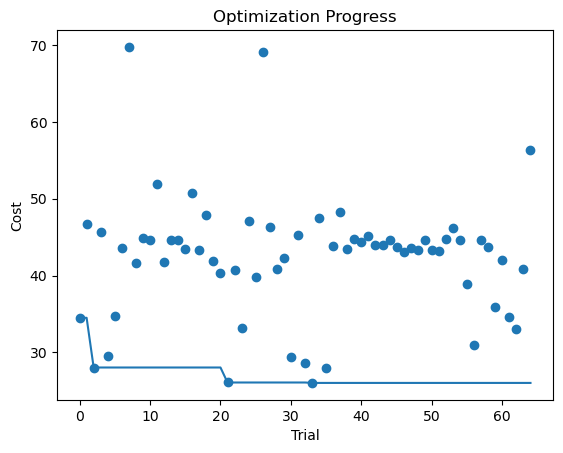

In [107]:
df_plot = DF_optuna.copy()

df_plot["Trial"] = range(len(df_plot))
df_plot["Best So Far"] = df_plot["Cost"].cummin()

fig, ax = plt.subplots()

ax.scatter(df_plot["Trial"], df_plot["Cost"])
ax.plot(df_plot["Trial"], df_plot["Best So Far"])

ax.set_xlabel("Trial")
ax.set_ylabel("Cost")
ax.set_title("Optimization Progress")

plt.show()

In [110]:
df_plot["Improvement"] = (
    df_plot["Best So Far"].shift(1)
    - df_plot["Best So Far"]
)

df_plot.loc[
    df_plot["Improvement"] > 0,
    ["Trial", "Run Name", "Cost", "Best So Far", "Improvement"]
]

,Trial,Run Name,Cost,Best So Far,Improvement
2,2,C11,28.036106,28.036106,6.468732
21,21,C7,26.084536,26.084536,1.951571
33,33,C8,26.029243,26.029243,0.055292


### 9.1.2. By bottom pH

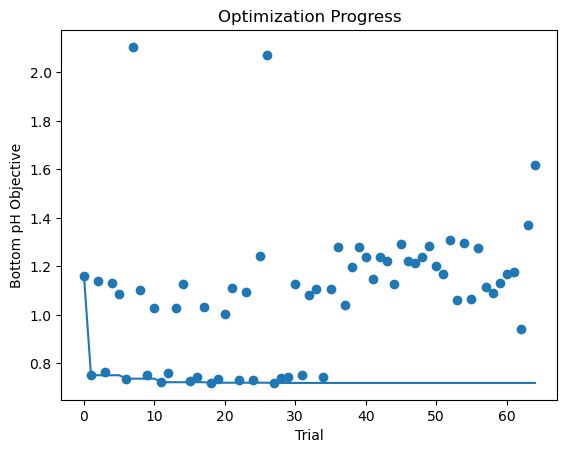

In [113]:
df_plot = DF_optuna.copy()

df_plot["Trial"] = range(len(df_plot))
df_plot["Best So Far"] = df_plot["Bottom pH Objective"].cummin()

fig, ax = plt.subplots()

ax.scatter(df_plot["Trial"], df_plot["Bottom pH Objective"])
ax.plot(df_plot["Trial"], df_plot["Best So Far"])

ax.set_xlabel("Trial")
ax.set_ylabel("Bottom pH Objective")
ax.set_title("Optimization Progress")

plt.show()

In [114]:
df_plot["Improvement"] = (
    df_plot["Best So Far"].shift(1)
    - df_plot["Best So Far"]
)

df_plot.loc[
    df_plot["Improvement"] > 0,
    ["Trial", "Run Name", "Bottom pH Objective", "Best So Far", "Improvement"]
]

,Trial,Run Name,Bottom pH Objective,Best So Far,Improvement
1,1,A17,0.750754,0.750754,0.410708
6,6,LHS_5,0.736598,0.736598,0.014156
11,11,LHS_12,0.721985,0.721985,0.014612
18,18,LHS_3,0.719942,0.719942,0.002043
27,27,LHS_2,0.719044,0.719044,0.000898


## 9.2. Parameter Stability

| Column              | Definition                                                                                    | How to interpret                                                                                                                                             |
| ------------------- | --------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **All Range**       | Maximum parameter value minus minimum parameter value across all runs.                        | The total portion of parameter space that has been explored for that parameter.                                                                              |
| **Top 20% Range**   | Maximum minus minimum parameter value among only the best 20% of runs, ranked by lowest Cost. | Shows how much that parameter still varies among the best-performing runs.                                                                                   |
| **Range Fraction**  | `Top 20% Range / All Range`                                                                   | Values near **0** mean the best runs occupy a narrow part of the explored range; values near **1** mean the best runs still span most of the explored range. |
| **All Unique**      | Number of distinct parameter values across all runs.                                          | Indicates how well sampled that parameter is. Low values mean there were only a few discrete settings tested.                                                |
| **Top 20% Unique**  | Number of distinct parameter values among the best 20% of runs.                               | Shows how many different settings still appear among good runs.                                                                                              |
| **Unique Fraction** | `Top 20% Unique / All Unique`                                                                 | Values near **0** mean good runs concentrate on relatively few parameter values; values near **1** mean good runs retain most of the tested values.          |


In [125]:
top_fraction = 0.20

n_top = max(3, int(len(DF_optuna) * top_fraction))

top_runs = (
    DF_optuna
    .dropna(subset=["Cost"])
    .nsmallest(n_top, "Cost")
)

parameter_stability = pd.DataFrame(index=varied_parameter_cols)

parameter_stability["All Range"] = (
    DF_optuna[varied_parameter_cols].max()
    - DF_optuna[varied_parameter_cols].min()
)

parameter_stability["Top 20% Range"] = (
    top_runs[varied_parameter_cols].max()
    - top_runs[varied_parameter_cols].min()
)

parameter_stability["Range Fraction"] = (
    parameter_stability["Top 20% Range"]
    / parameter_stability["All Range"]
)

parameter_stability["All Unique"] = (
    DF_optuna[parameter_stability.index].nunique()
)

parameter_stability["Top 20% Unique"] = (
    top_runs[parameter_stability.index].nunique()
)

parameter_stability["Unique Fraction"] = (
    parameter_stability["Top 20% Unique"]
    / parameter_stability["All Unique"]
)

parameter_stability[
    [
        "All Range",
        "Top 20% Range",
        "Range Fraction",
        "All Unique",
        "Top 20% Unique",
        "Unique Fraction"
    ]
]

parameter_stability = parameter_stability.sort_values(
    "Unique Fraction"
)

parameter_stability

,All Range,Top 20% Range,Range Fraction,All Unique,Top 20% Unique,Unique Fraction
bUmax_nspc0,0.449618,0.000000,0.000000,15,1,0.066667
bgamma5,0.249760,0.088564,0.354595,39,4,0.102564
bdenit,26.105877,16.233524,0.621834,38,4,0.105263
bgamma7,0.246145,0.211173,0.857921,37,4,0.108108
wsd,3.000000,1.571129,0.523710,26,4,0.153846
bnit,0.148785,0.093655,0.629468,24,4,0.166667
bUmax_nspc1,0.017260,0.012824,0.742965,28,5,0.178571
amaxs1,0.080000,0.000000,0.000000,3,1,0.333333
wsdsi,3.000000,0.000000,0.000000,3,1,0.333333
beta1,1.750000,0.170721,0.097555,6,2,0.333333


## 9.3. Which parameters are important for each objective?

With `RandomForestRegressor.feature_importances_`, sklearn uses impurity-based importance. For regression, “impurity” is related to variance / squared error. A parameter gets more importance when splits using it produce large reductions in prediction error, especially when that happens frequently across the forest.

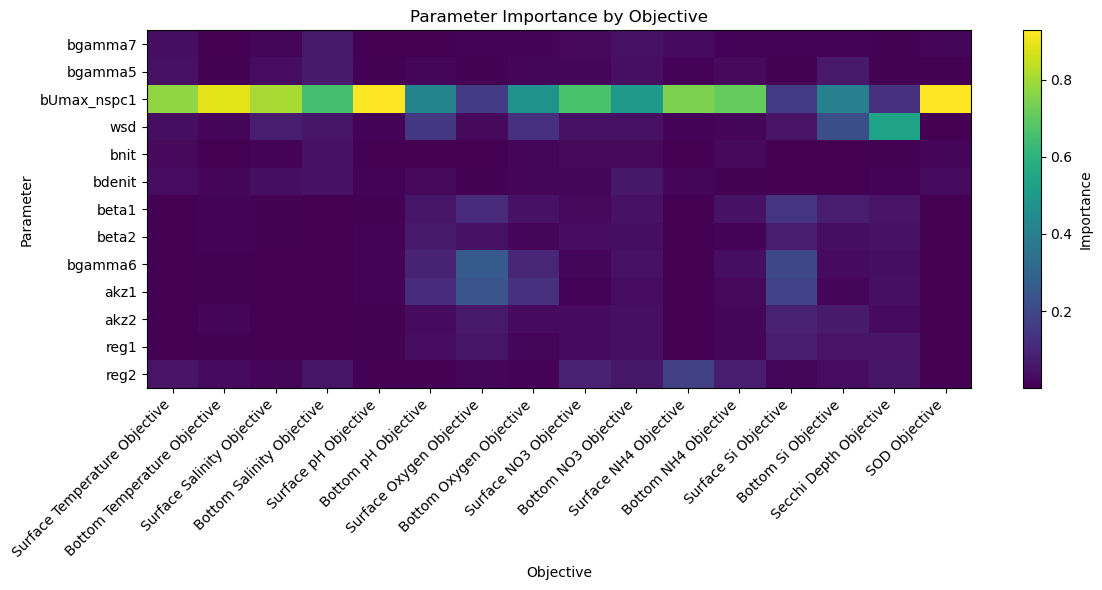

In [79]:
from sklearn.ensemble import RandomForestRegressor

importance_df = pd.DataFrame(index=active_parameters)

for objective in active_objective_cols:

    d = DF_optuna[active_parameters + [objective]].dropna()

    X = d[active_parameters]
    y = d[objective]

    model = RandomForestRegressor(
        n_estimators=500,
        random_state=42
    )

    model.fit(X, y)

    importance_df[objective] = model.feature_importances_

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    importance_df[active_objective_cols],
    aspect="auto"
)

ax.set_xticks(range(len(active_objective_cols)))
ax.set_xticklabels(active_objective_cols, rotation=45, ha="right")

ax.set_yticks(range(len(importance_df)))
ax.set_yticklabels(importance_df.index)

ax.set_xlabel("Objective")
ax.set_ylabel("Parameter")
ax.set_title("Parameter Importance by Objective")

plt.colorbar(im, ax=ax, label="Importance")
plt.tight_layout()

## 9.4. Spearman correlation matrix

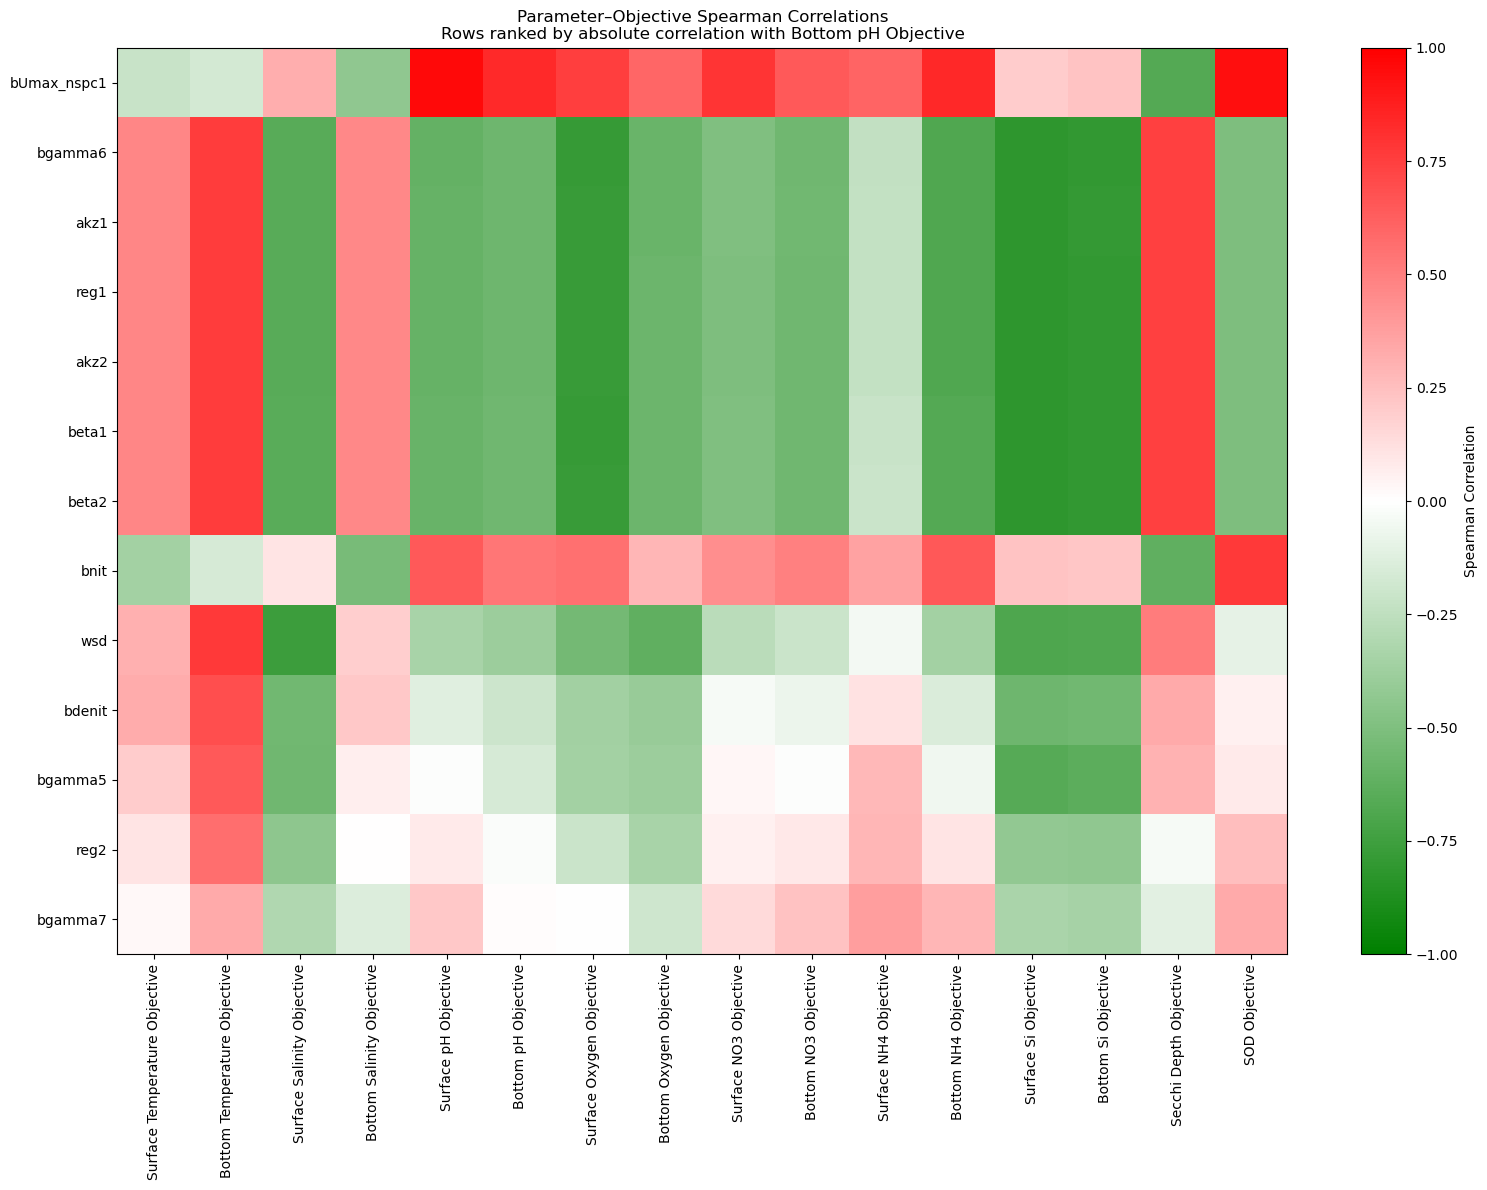

In [81]:
# --------------------------------
# Spearman correlation matrix
# --------------------------------

objective_parameter_corr = pd.DataFrame(
    index=active_parameters,
    columns=active_objective_cols,
    dtype=float
)

for parameter in active_parameters:
    for objective in active_objective_cols:

        objective_parameter_corr.loc[parameter, objective] = (
            DF_optuna[[parameter, objective]]
            .corr(method="spearman")
            .iloc[0, 1]
        )
        
from matplotlib.colors import LinearSegmentedColormap

# --------------------------------
# Sort parameters by Bottom pH importance
# --------------------------------

rank_objective = "Bottom pH Objective"

objective_parameter_corr_heatmap = (
    objective_parameter_corr
    .loc[
        objective_parameter_corr[rank_objective]
        .abs()
        .sort_values(ascending=False)
        .index
    ]
)

# --------------------------------
# Custom colormap:
# green = improvement when parameter increases
# red   = worsening when parameter increases
# --------------------------------

green_red_cmap = LinearSegmentedColormap.from_list(
    "green_white_red",
    ["green", "white", "red"]
)

# --------------------------------
# Plot heatmap
# --------------------------------

plt.figure(figsize=(16, 12))

plt.imshow(objective_parameter_corr_heatmap,
           aspect="auto",
           vmin=-1,
           vmax=1,
           cmap=green_red_cmap)

plt.colorbar(label="Spearman Correlation")

plt.xticks(range(len(objective_parameter_corr_heatmap.columns)),
           objective_parameter_corr_heatmap.columns,
           rotation=90)

plt.yticks(range(len(objective_parameter_corr_heatmap.index)),
           objective_parameter_corr_heatmap.index)

plt.title("Parameter–Objective Spearman Correlations\n"
          f"Rows ranked by absolute correlation with {rank_objective}")

plt.tight_layout()
plt.show()

## 9.5. Pairwise interaction screening with cross validation

* `Delta CV R2 > 0`: adding the interaction improved out-of-sample prediction.
  * Larger positive values: stronger evidence that the pair has a meaningful interaction.
* `Delta CV R2 ≈ 0:` little added value from the interaction.
* `Delta CV R2 < 0`: the interaction actually hurt cross-validated performance, so I would not consider that pair meaningful.

### 9.5.1. calculate the interaction

In [99]:
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold

interaction_results = []

objective = "Bottom pH Objective"

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for p1, p2 in combinations(active_parameters, 2):

    d = DF_optuna[[objective, p1, p2]].dropna().copy()

    if len(d) < 10:
        continue

    scaler = StandardScaler()

    X_main = scaler.fit_transform(
        d[[p1, p2]]
    )

    y = d[objective].values

    interaction = (
        X_main[:, 0] * X_main[:, 1]
    ).reshape(-1, 1)

    X_interaction = np.column_stack([
        X_main,
        interaction
    ])

    model = LinearRegression()

    r2_main = cross_val_score(
        model,
        X_main,
        y,
        cv=cv,
        scoring="r2"
    ).mean()

    r2_interaction = cross_val_score(
        model,
        X_interaction,
        y,
        cv=cv,
        scoring="r2"
    ).mean()

    interaction_results.append({
        "Parameter 1": p1,
        "Parameter 2": p2,
        "CV R2 main": r2_main,
        "CV R2 interaction": r2_interaction,
        "Delta CV R2": r2_interaction - r2_main,
        "N": len(d)
    })

interaction_results = pd.DataFrame(interaction_results)

interaction_results = (
    interaction_results
    .sort_values(
        "Delta CV R2",
        ascending=False
    )
)

### 9.5.2. visualize strength of interactions

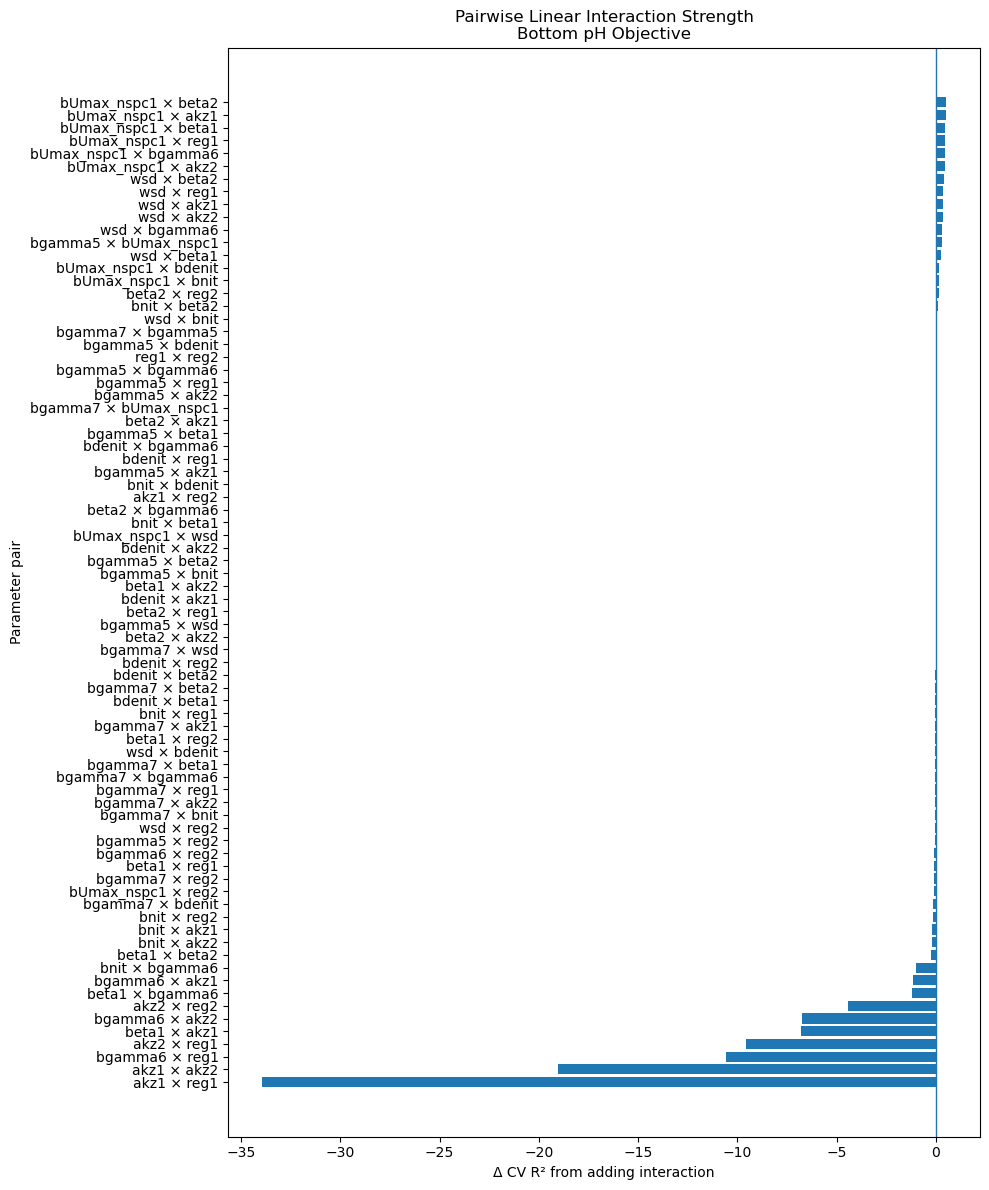

In [86]:
plot_df = interaction_results.copy()

plot_df["Interaction"] = (
    plot_df["Parameter 1"]
    + " × "
    + plot_df["Parameter 2"]
)

plot_df = plot_df.sort_values(
    "Delta CV R2",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(
    plot_df["Interaction"],
    plot_df["Delta CV R2"]
)

ax.axvline(0, linewidth=1)

ax.set_xlabel("Δ CV R² from adding interaction")
ax.set_ylabel("Parameter pair")
ax.set_title(
    f"Pairwise Linear Interaction Strength\n{objective}"
)

plt.tight_layout()
plt.show()

### 9.5.3. visualize the nature of top 10 interacting params

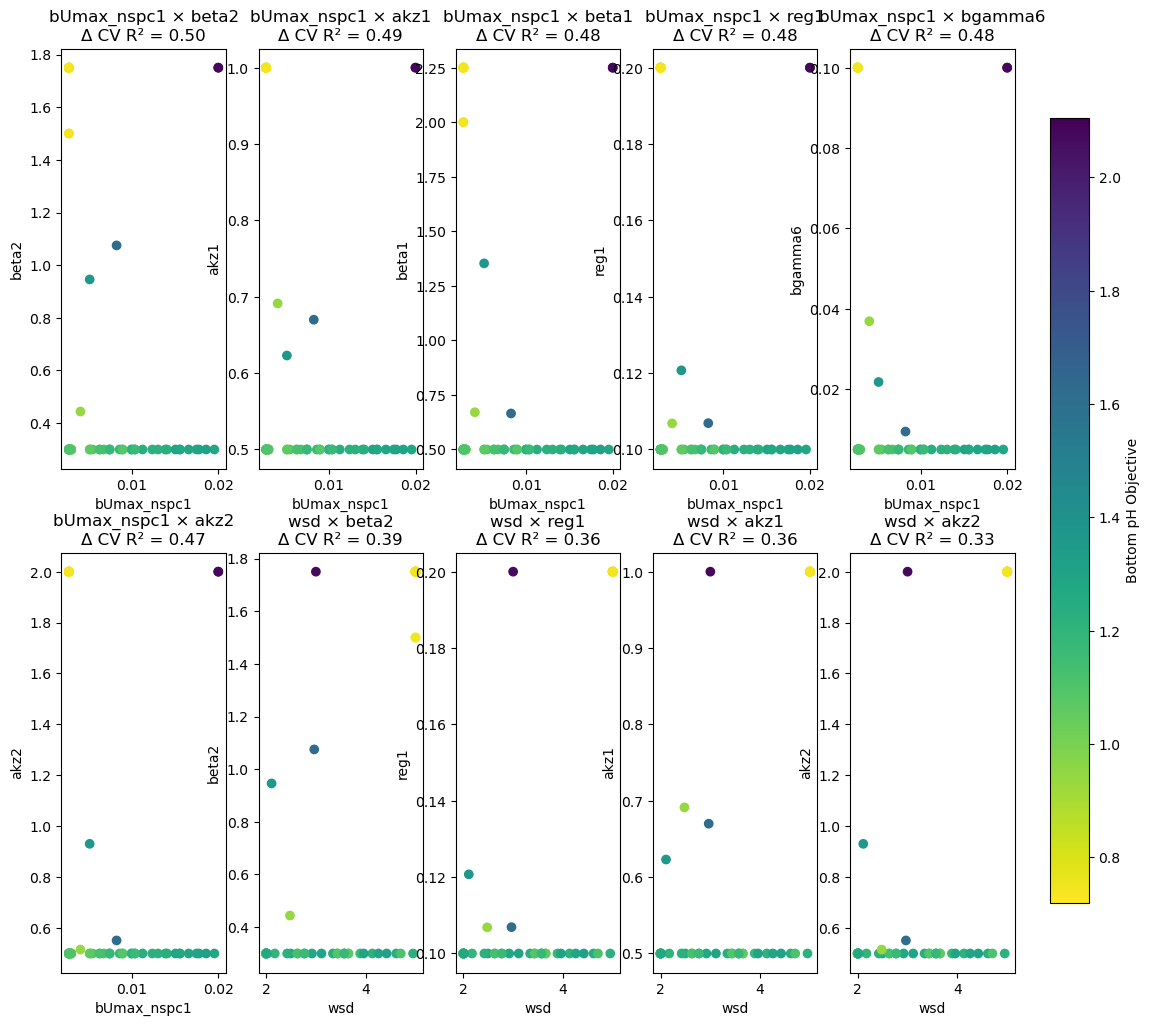

In [98]:
import matplotlib as mpl

objective = "Bottom pH Objective"

top5 = interaction_results.head(10)

fig, axarr = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(15, 12)
)

axarr = axarr.flatten()

# --------------------------------
# Common color scale for ALL plots
# --------------------------------

vmin = DF_optuna[objective].min()
vmax = DF_optuna[objective].max()

norm = mpl.colors.Normalize(
    vmin=vmin,
    vmax=vmax
)

cmap = "viridis_r"

# --------------------------------
# Plot top 5 interactions
# --------------------------------

for i, (_, row) in enumerate(top5.iterrows()):

    p1 = row["Parameter 1"]
    p2 = row["Parameter 2"]

    d = DF_optuna[
        [p1, p2, objective]
    ].dropna()

    axarr[i].scatter(
        d[p1],
        d[p2],
        c=d[objective],
        cmap=cmap,
        norm=norm
    )

    axarr[i].set_xlabel(p1)
    axarr[i].set_ylabel(p2)

    axarr[i].set_title(
        f"{p1} × {p2}\n"
        f"Δ CV R² = {row['Delta CV R2']:.2f}"
    )

# --------------------------------
# Remove unused axes
# --------------------------------

for j in range(len(top5), len(axarr)):
    fig.delaxes(axarr[j])

# --------------------------------
# One shared colorbar
# --------------------------------

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

cbar = fig.colorbar(
    sm,
    ax=axarr[:len(top5)],
    label=objective,
    shrink=0.85,
    pad=0.03
)

plt.show()

## 9.6. Pairwise nonlinear interactions

In [101]:
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.linear_model import Ridge

nonlinear_interaction_results = []

objective = "Bottom pH Objective"

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for p1, p2 in combinations(active_parameters, 2):

    d = DF_optuna[[objective, p1, p2]].dropna().copy()

    if len(d) < 10:
        continue

    y = d[objective].values

    # --------------------------------
    # Standardize parameters
    # --------------------------------

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        d[[p1, p2]]
    )

    # --------------------------------
    # Create nonlinear spline basis
    # --------------------------------

    spline = SplineTransformer(
        n_knots=4,
        degree=3,
        include_bias=False
    )

    B1 = spline.fit_transform(
        X_scaled[:, 0].reshape(-1, 1)
    )

    B2 = spline.fit_transform(
        X_scaled[:, 1].reshape(-1, 1)
    )

    # --------------------------------
    # Additive nonlinear model
    #
    # nonlinear(p1) + nonlinear(p2)
    # --------------------------------

    X_additive = np.column_stack([
        B1,
        B2
    ])

    # --------------------------------
    # Nonlinear interaction terms
    # --------------------------------

    interaction_terms = []

    for i in range(B1.shape[1]):
        for j in range(B2.shape[1]):

            interaction_terms.append(
                B1[:, i] * B2[:, j]
            )

    X_interactions = np.column_stack(
        interaction_terms
    )

    X_full = np.column_stack([
        X_additive,
        X_interactions
    ])

    # --------------------------------
    # Regularized regression
    # --------------------------------

    model = Ridge(alpha=1.0)

    # Additive nonlinear model
    r2_additive = cross_val_score(
        model,
        X_additive,
        y,
        cv=cv,
        scoring="r2"
    ).mean()

    # Add nonlinear interaction
    r2_interaction = cross_val_score(
        model,
        X_full,
        y,
        cv=cv,
        scoring="r2"
    ).mean()

    nonlinear_interaction_results.append({
        "Parameter 1": p1,
        "Parameter 2": p2,
        "CV R2 additive": r2_additive,
        "CV R2 nonlinear interaction": r2_interaction,
        "Delta CV R2": r2_interaction - r2_additive,
        "N": len(d)
    })

In [104]:
nonlinear_interaction_results = pd.DataFrame(
    nonlinear_interaction_results
)

nonlinear_interaction_results = (
    nonlinear_interaction_results
    .sort_values(
        "Delta CV R2",
        ascending=False
    )
)

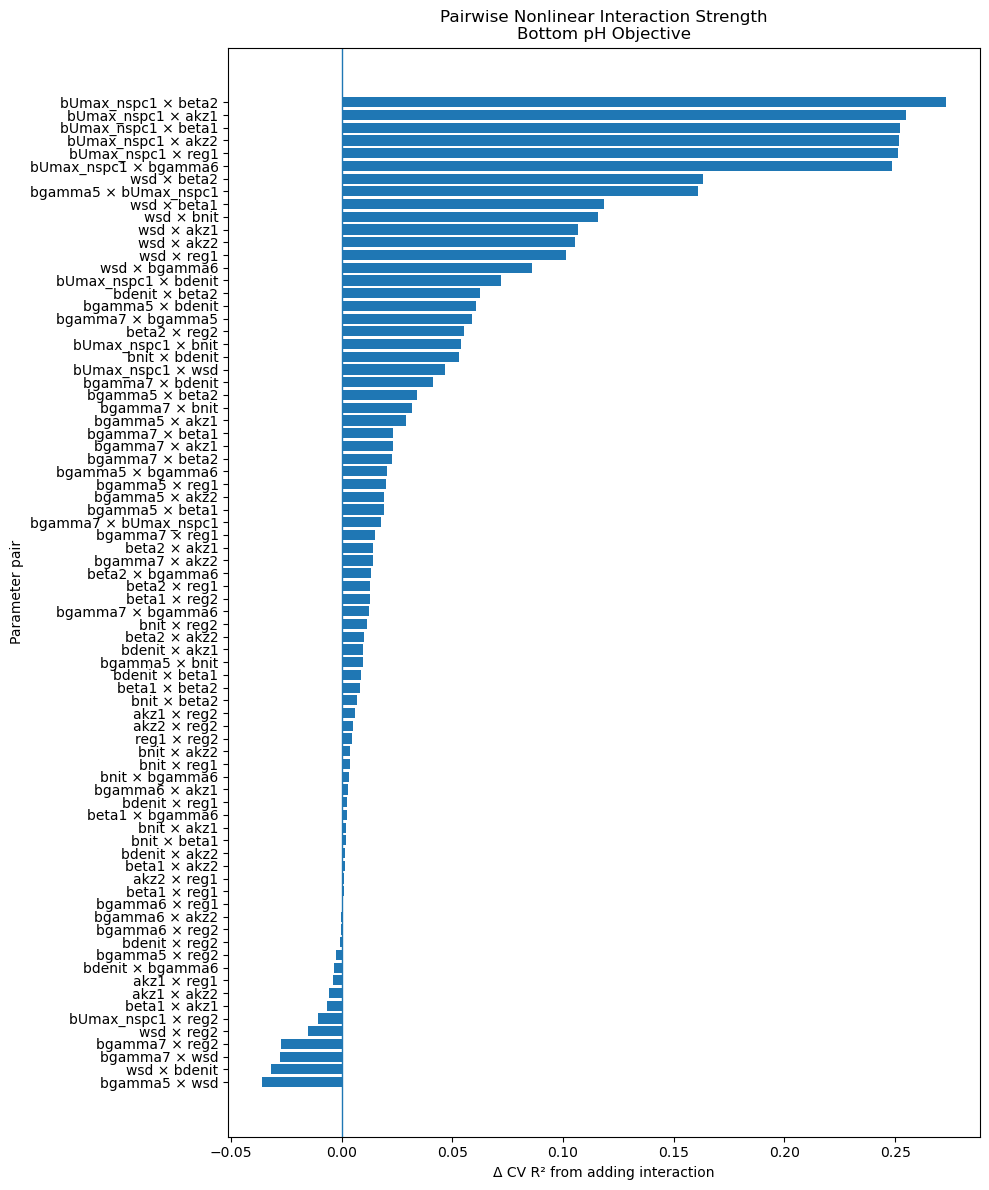

In [103]:
plot_df = nonlinear_interaction_results.copy()

plot_df["Interaction"] = (
    plot_df["Parameter 1"]
    + " × "
    + plot_df["Parameter 2"]
)

plot_df = plot_df.sort_values(
    "Delta CV R2",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(
    plot_df["Interaction"],
    plot_df["Delta CV R2"]
)

ax.axvline(0, linewidth=1)

ax.set_xlabel("Δ CV R² from adding interaction")
ax.set_ylabel("Parameter pair")
ax.set_title(
    f"Pairwise Nonlinear Interaction Strength\n{objective}"
)

plt.tight_layout()
plt.show()